# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [916]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs('distinct')

chromatin_model1 = ChromatinModel(config1)

todo: Loading testing config from replication deconvolution


In [918]:
mnase_span = (771600, 771900)
chromatin_model1.load_mnase_span(chrom=16, mnase_span=mnase_span)

Already loaded chromosome reads for 16. Using cache.
Applying a normalization for length distribution


In [935]:
from src.chromatin_deconvolution_solver import example_N_frep_b

padding_type = 'both'
N, f_rep, b = example_N_frep_b(config1)


In [1015]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma

chromatin_solver = ChromatinDeconvolveSolver(config1, 
    chromatin_model1.G, N, b, f_rep,
    padding_type='both', subsample=5)

Subsampling to top 5 sites
Indices with the highest max value:  [513 513 513 493 544 483 757 493 513 483 483 483 513 544 544 487]


In [1036]:
chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver, gamma_min=0.0001, gamma_max=0.001)

	Base error (γ=0):	rn: 0.008989	sn: 74.749559
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.0094385
			Absolute (e0 + 0.04): 0.0489891
			Chosen: 0.009439
		Right:
			Relative (4.0 * e0): 0.0359562
			Absolute (e0 + 0.32): 11.009
			Chosen: 11.008989
	Searching for left boundary gamma...
		γ: 0.00055	rn: 0.0247	sn: 0.1988
		γ: 0.000325	rn: 0.0210	sn: 0.2493
		γ: 0.0002125	rn: 0.0181	sn: 0.3161
		γ: 0.00015625	rn: 0.0166	sn: 0.3714
		γ: 0.000128125	rn: 0.0157	sn: 0.4073
		γ: 0.000114063	rn: 0.0154	sn: 0.4256
		γ: 0.000107031	rn: 0.0152	sn: 0.4372
		γ: 0.000103516	rn: 0.0151	sn: 0.4437
		γ: 0.000101758	rn: 0.0150	sn: 0.4475
		γ: 0.000100879	rn: 0.0150	sn: 0.4493
	Left boundary gamma found: 0.000100439
	Searching for right boundary gamma...
		γ: 0.00055022	rn: 0.0247	sn: 0.1988
		γ: 0.00077511	rn: 0.0281	sn: 0.1721
		γ: 0.000887555	rn: 0.0300	sn: 0.1608
		γ: 0.000943777	rn: 0.0311	sn: 0.1551
		γ: 0.000971889	rn: 0.0315	sn: 0.1529
		γ: 0.000985944	rn: 0.0316	sn: 0.1518
		γ: 0.00099

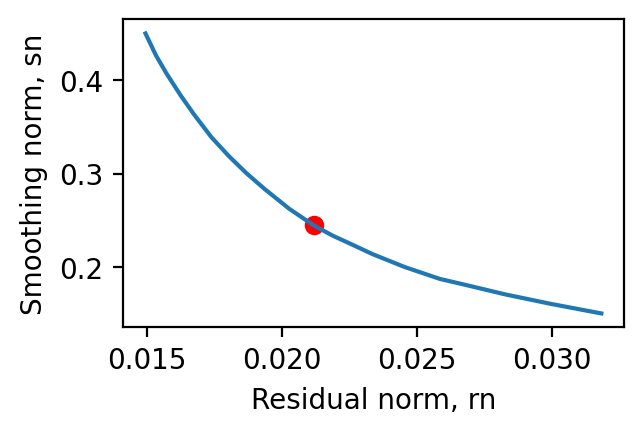

In [1037]:
chrom_find_gamma.find_optimal_gamma()

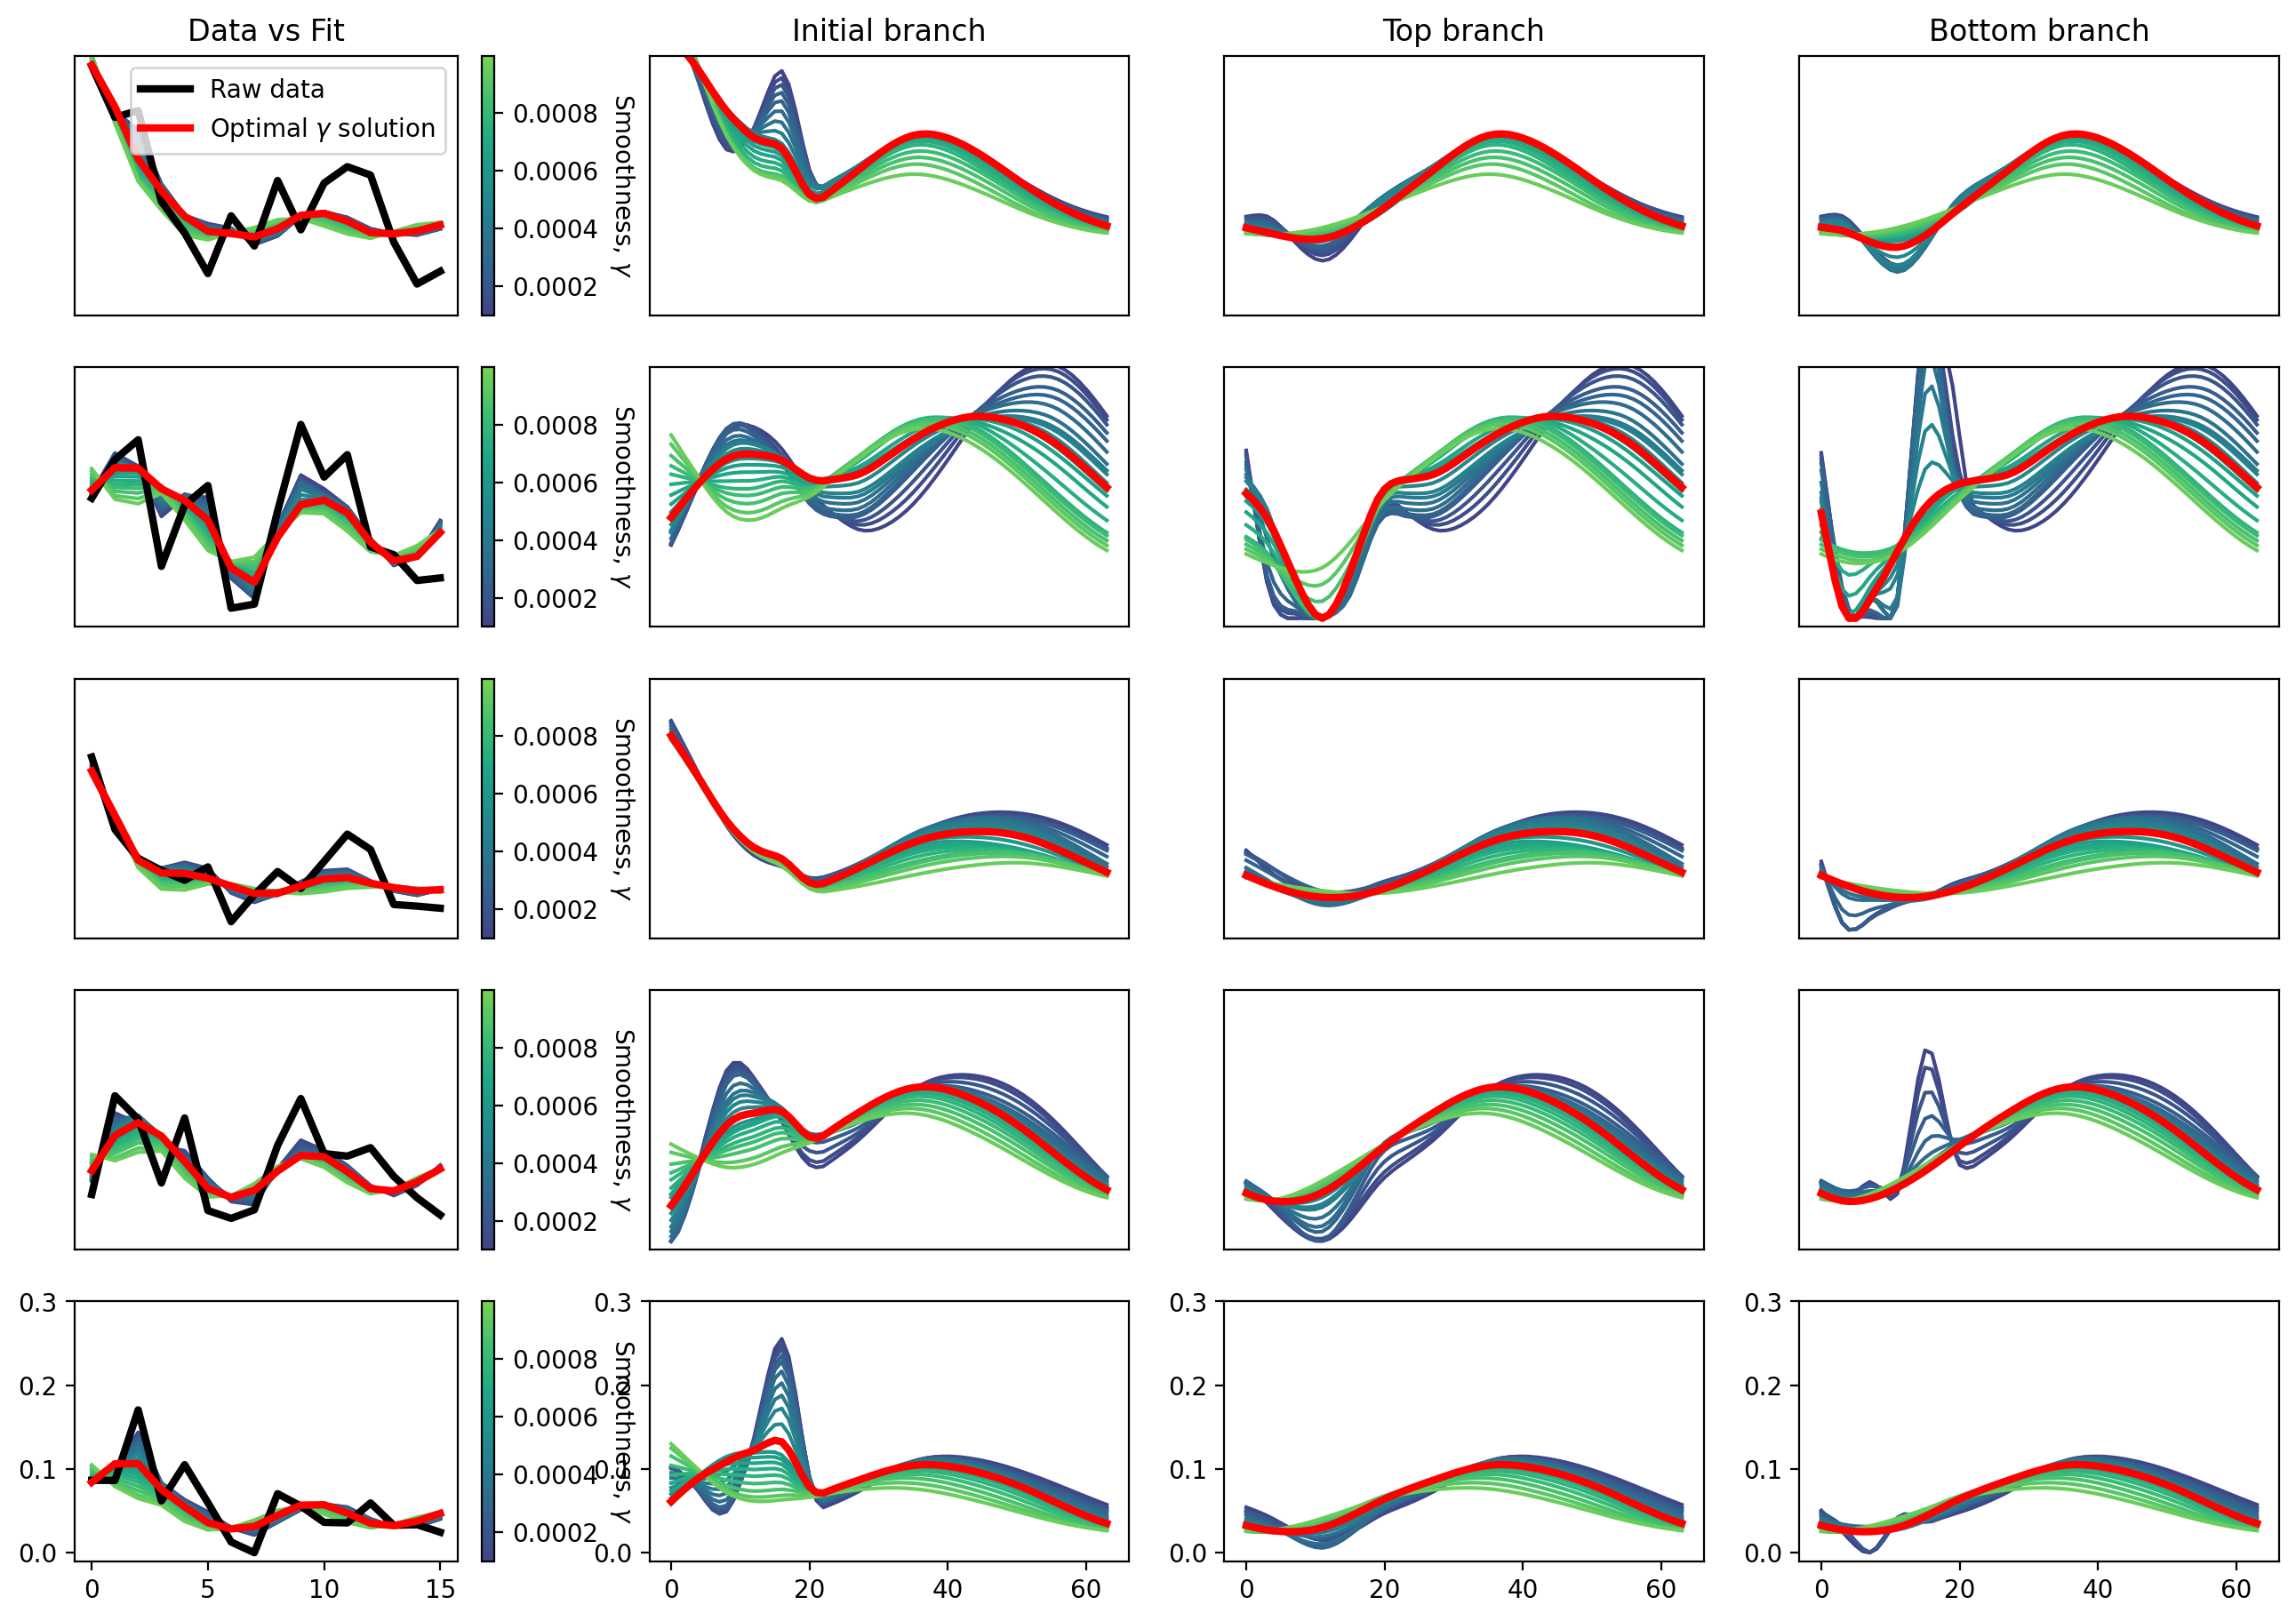

In [1038]:
gamma_predicted_Gs_test = chrom_find_gamma.plot_gamma_sweep()

In [986]:
chromatin_solver_full = ChromatinDeconvolveSolver(config1, 
    chromatin_model1.G, N, b, f_rep, padding_type=padding_type)
#full_deconvolved_F = chromatin_solver_full.deconvolve_G_iteratively(
#    gamma=chrom_find_gamma.gamma_optimizer.optimal_gamma)

0/780 - 00:00:00.000
500/780 - 00:01:38.993


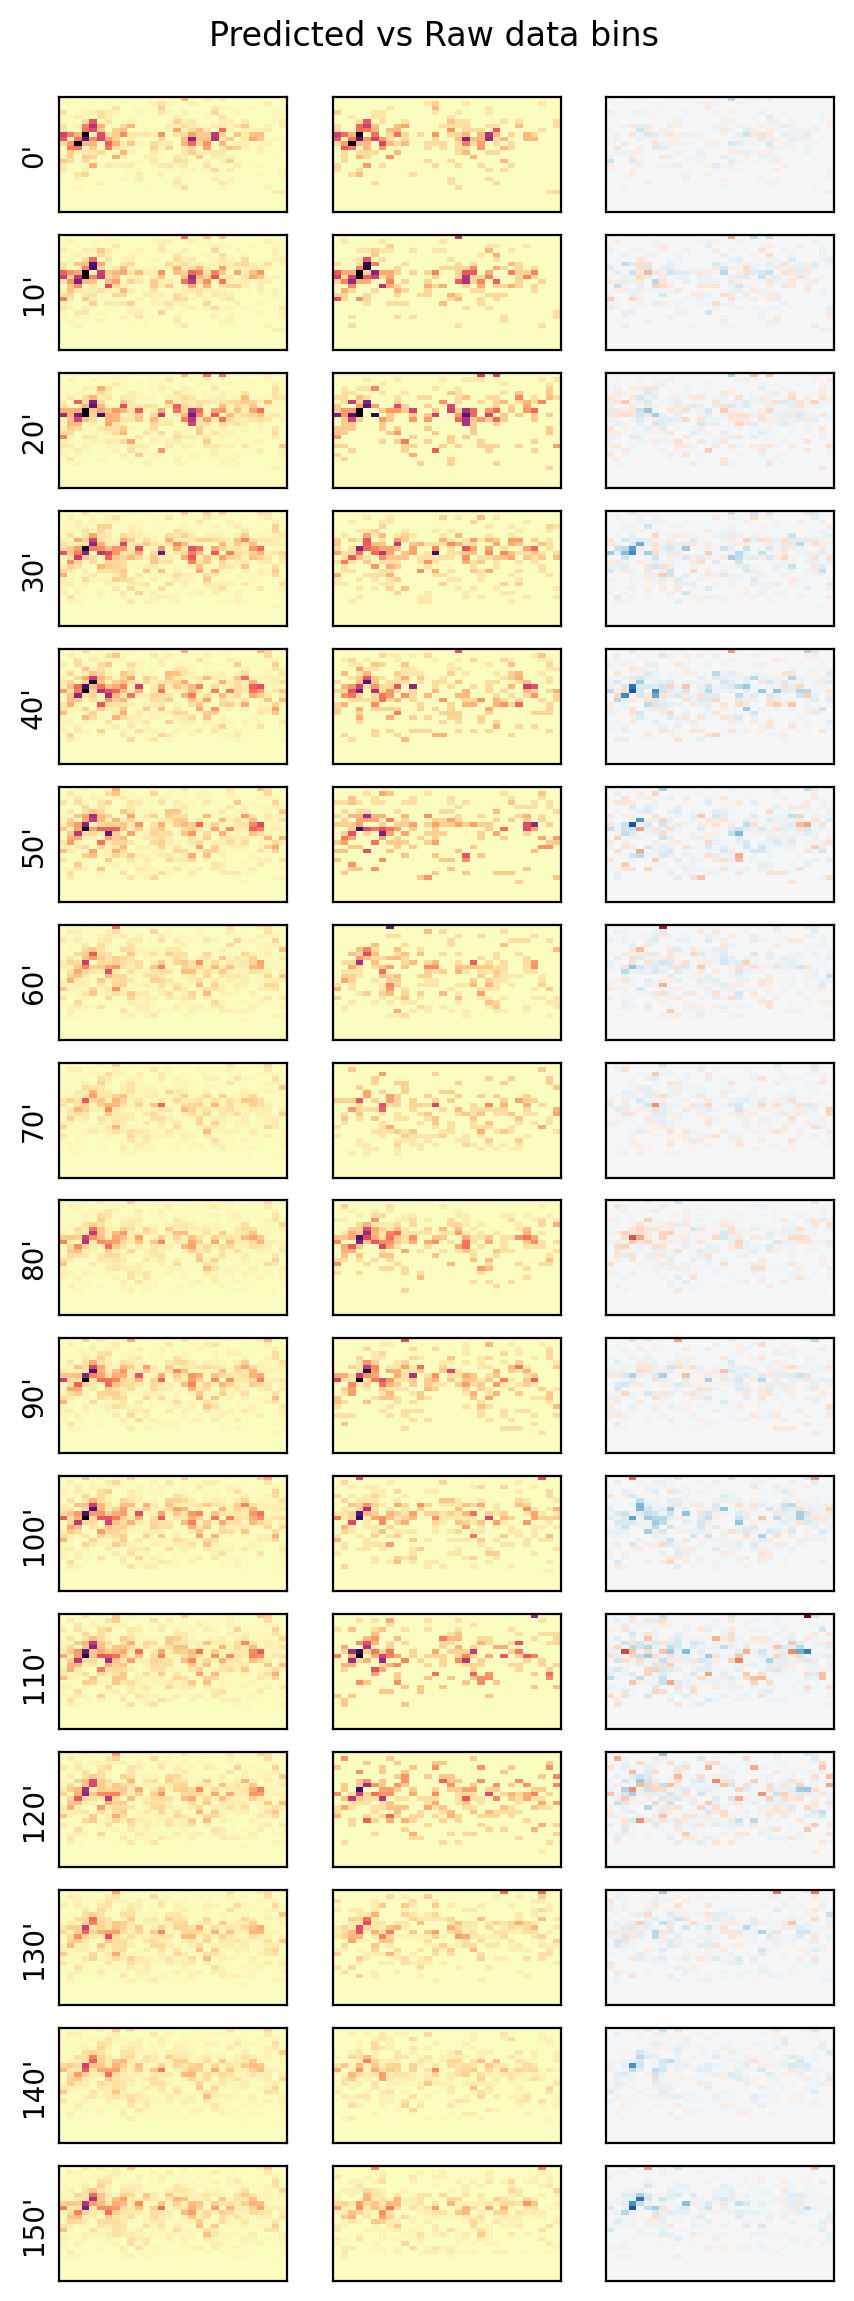

In [987]:
from src.chromatin_model import plot_prediction

plot_prediction(config1, N, full_deconvolved_F, f_rep, G, b)


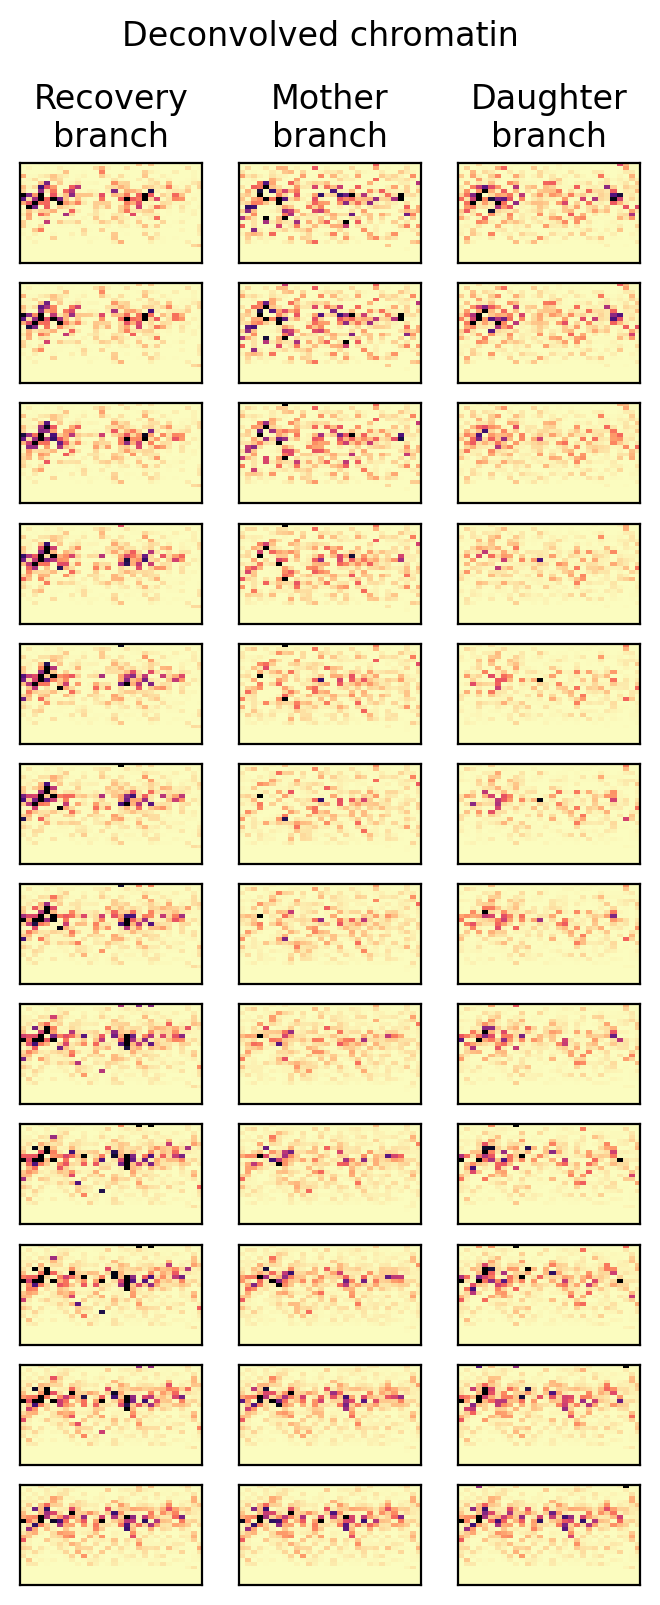

In [991]:

i_indices = config1.get_Hpositions_for_branch('i')
t_indices = config1.get_Hpositions_for_branch('t')
b_indices = config1.get_Hpositions_for_branch('b')

r_indices = config1.get_Hpositions_for_phase('RG1')
c_indices = config1.get_Hpositions_for_phase('CG1')
d_indices = config1.get_Hpositions_for_phase('DG1')

full_F_imgs = full_deconvolved_F.reshape((full_deconvolved_F.shape[0], 26, -1))
full_F_imgs.shape

num_imgs_per_branch = 12

fig, axs = plt.subplots(num_imgs_per_branch, 3, figsize=(4, 9))
axs = np.array(axs).T

def plot_branch_imgs(row_axs, t_indices):

    for plot_index, index_in_t in enumerate(np.linspace(0,
        len(t_indices)-1, num_imgs_per_branch)):
        image_index = t_indices[int(index_in_t)]

        ax = row_axs[plot_index]
        ax.imshow(full_F_imgs[image_index], aspect='auto', cmap='magma_r', vmax=0.1,
                  origin='lower')
        ax.set_xticks([])
        ax.set_yticks([])
        
plot_branch_imgs(axs[0], r_indices)
plot_branch_imgs(axs[1], c_indices)
plot_branch_imgs(axs[2], d_indices)

axs[0][0].set_title("Recovery\nbranch")
axs[1][0].set_title("Mother\nbranch")
axs[2][0].set_title("Daughter\nbranch")

plt.suptitle("Deconvolved chromatin")
plt.subplots_adjust(top=0.9)